# Loan Approval Prediction Using XGBoost Machine Learning

# Developed by DEEPAK.M AI Generalist iPEC Solutions Private Limited Bangalore
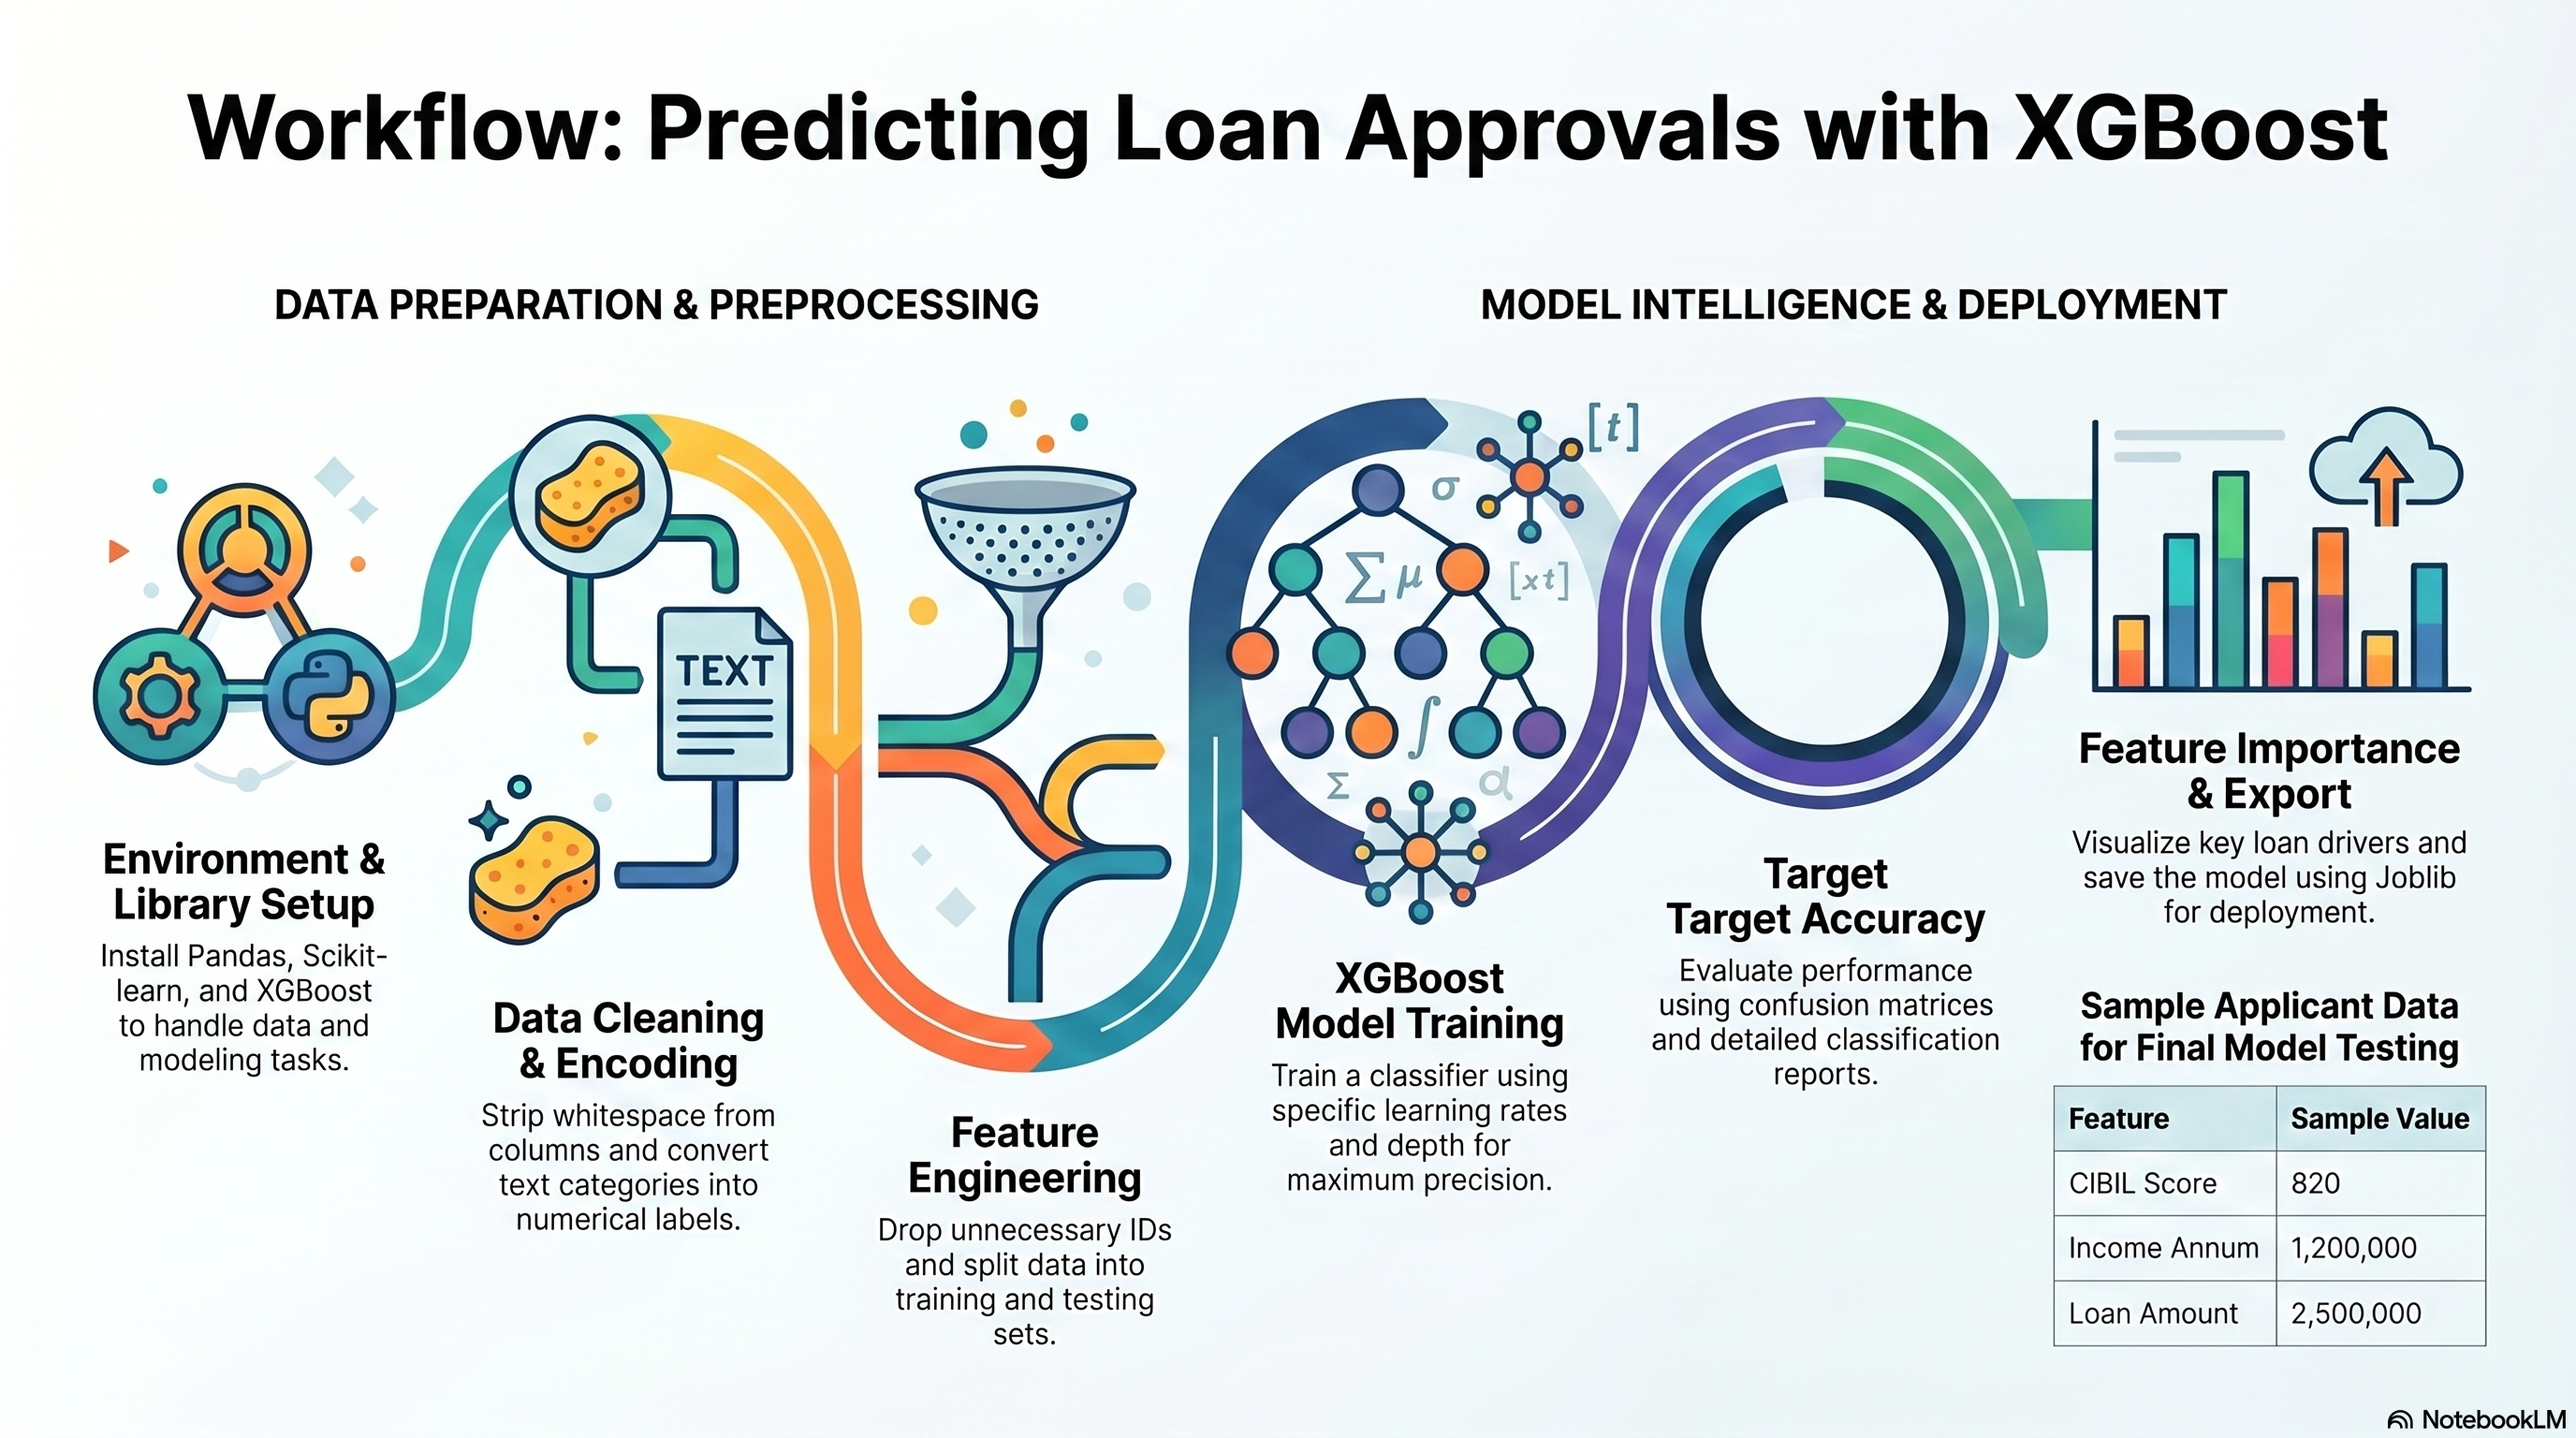

# 1.Import Linraries

In [3]:
#!pip install xgboost

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# 2.Read Dataset

In [31]:
df=pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## Remove Extra Spaces from Column Names

In [36]:
df.columns = df.columns.str.strip()

# 3.Explore Data

In [37]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   int64
 3   self_employed             4269 non-null   int64
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   int64
dtypes: int64(13)
memory usage: 433.7 KB


(4269, 13)

# 4.Check Missing Values

In [52]:
df.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

# 5.Remove Loan ID

In [39]:
df.drop("loan_id", axis=1, inplace=True)

# 6.Encode Categorical Columns

In [40]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["education"] = le.fit_transform(df["education"])
df["self_employed"] = le.fit_transform(df["self_employed"])
df["loan_status"] = le.fit_transform(df["loan_status"])

# 7.Define X and y

In [41]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

# 8.Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 9.Train XGBoost

In [43]:
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# 10.Prediction

In [44]:
y_pred = model.predict(X_test)

# 11.Accuracy

In [45]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9754098360655737


# 12.Confusion Matrix

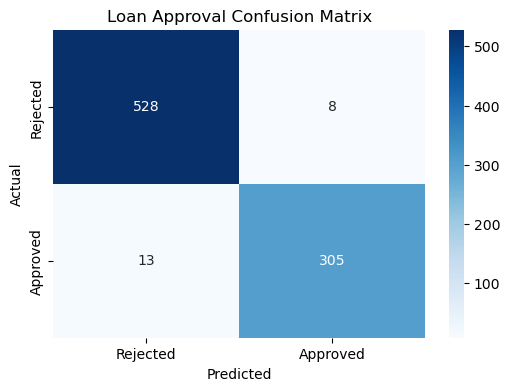

In [53]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected','Approved'],
    yticklabels=['Rejected','Approved']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Loan Approval Confusion Matrix')
plt.show()

# 13.Classification Report

In [47]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.97      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



# 14.Feature Importance

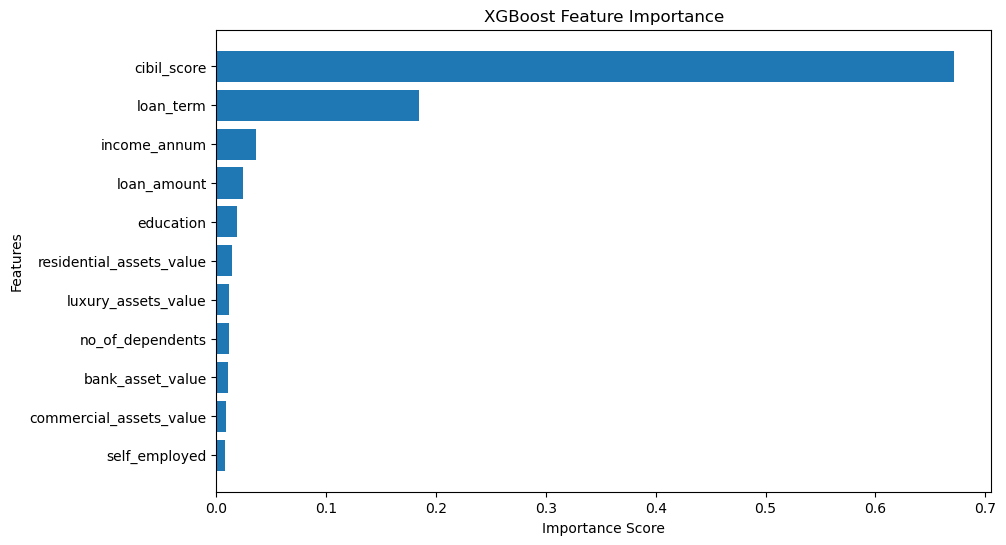

In [55]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# 15.Save Model

In [49]:
import joblib
joblib.dump(model, "loan_xgboost.pkl")

['loan_xgboost.pkl']

# 16.New Samples

In [58]:
import pandas as pd

new_samples = pd.DataFrame([
    {
        "no_of_dependents": 1,
        "education": 1,
        "self_employed": 0,
        "income_annum": 1200000,
        "loan_amount": 2500000,
        "loan_term": 15,
        "cibil_score": 820,
        "residential_assets_value": 4000000,
        "commercial_assets_value": 1000000,
        "luxury_assets_value": 2000000,
        "bank_asset_value": 1500000
    },

    {
        "no_of_dependents": 4,
        "education": 0,
        "self_employed": 1,
        "income_annum": 250000,
        "loan_amount": 6000000,
        "loan_term": 20,
        "cibil_score": 450,
        "residential_assets_value": 200000,
        "commercial_assets_value": 0,
        "luxury_assets_value": 50000,
        "bank_asset_value": 25000
    },

    {
        "no_of_dependents": 2,
        "education": 1,
        "self_employed": 0,
        "income_annum": 1800000,
        "loan_amount": 3500000,
        "loan_term": 10,
        "cibil_score": 900,
        "residential_assets_value": 8000000,
        "commercial_assets_value": 4000000,
        "luxury_assets_value": 6000000,
        "bank_asset_value": 3000000
    },

    {
        "no_of_dependents": 3,
        "education": 1,
        "self_employed": 1,
        "income_annum": 700000,
        "loan_amount": 4500000,
        "loan_term": 18,
        "cibil_score": 600,
        "residential_assets_value": 1500000,
        "commercial_assets_value": 500000,
        "luxury_assets_value": 300000,
        "bank_asset_value": 100000
    },

    {
        "no_of_dependents": 0,
        "education": 1,
        "self_employed": 0,
        "income_annum": 2500000,
        "loan_amount": 2000000,
        "loan_term": 8,
        "cibil_score": 880,
        "residential_assets_value": 10000000,
        "commercial_assets_value": 5000000,
        "luxury_assets_value": 7000000,
        "bank_asset_value": 4000000
    }
])

predictions = model.predict(new_samples)

print(predictions)

[0 1 0 0 0]


In [59]:
new_samples["Prediction"] = predictions

print(new_samples)

   no_of_dependents  education  self_employed  income_annum  loan_amount  \
0                 1          1              0       1200000      2500000   
1                 4          0              1        250000      6000000   
2                 2          1              0       1800000      3500000   
3                 3          1              1        700000      4500000   
4                 0          1              0       2500000      2000000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         15          820                   4000000                  1000000   
1         20          450                    200000                        0   
2         10          900                   8000000                  4000000   
3         18          600                   1500000                   500000   
4          8          880                  10000000                  5000000   

   luxury_assets_value  bank_asset_value  Prediction  
0      

In [60]:
new_samples["Loan_Status"] = new_samples["Prediction"].map({
    1: "Approved",
    0: "Rejected"
})

print(new_samples[[
    "income_annum",
    "loan_amount",
    "cibil_score",
    "Loan_Status"
]])

   income_annum  loan_amount  cibil_score Loan_Status
0       1200000      2500000          820    Rejected
1        250000      6000000          450    Approved
2       1800000      3500000          900    Rejected
3        700000      4500000          600    Rejected
4       2500000      2000000          880    Rejected
